# <font color='magenta'>Metody rozwiązywania równań różniczkowych</font>
---
## Przykład - rozwiązanie równania różniczkowego za pomocą metody RK4.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Definicja równania różniczkowego

In [ ]:
def f(t, y):
    return -2 * y + t + 1

Rozwiązanie dokładne

In [ ]:
def exact(t):
    return (2*t + 1)/4 + (3/4)*np.exp(-2*t)

Implementacje metod Rungego-Kutty

In [ ]:
# Euler (RK1)
def rk1(f, y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(1, len(t)):
        y[i] = y[i-1] + h * f(t[i-1], y[i-1])
    return t, y

In [ ]:
# Heun (RK2)
def rk2(f, y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(1, len(t)):
        k1 = h * f(t[i-1], y[i-1])
        k2 = h * f(t[i-1] + h, y[i-1] + k1)
        y[i] = y[i-1] + (k1 + k2)/2
    return t, y

In [ ]:
# RK3
def rk3(f, y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(1, len(t)):
        k1 = h * f(t[i-1], y[i-1])
        k2 = h * f(t[i-1] + h/2, y[i-1] + k1/2)
        k3 = h * f(t[i-1] + h, y[i-1] - k1 + 2*k2)
        y[i] = y[i-1] + (k1 + 4*k2 + k3)/6
    return t, y

In [ ]:
# RK4
def rk4(f, y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(1, len(t)):
        k1 = h * f(t[i-1], y[i-1])
        k2 = h * f(t[i-1] + h/2, y[i-1] + k1/2)
        k3 = h * f(t[i-1] + h/2, y[i-1] + k2/2)
        k4 = h * f(t[i-1] + h, y[i-1] + k3)
        y[i] = y[i-1] + (k1 + 2*k2 + 2*k3 + k4)/6
    return t, y

Parametry

In [ ]:
y0 = 1.0    # Warunek początkowy
t0 = 0.0    # Czas początkowy
tf = 2.0    # Czas końcowy
h = 0.1     # Krok czasowy

Rozwiązanie

In [ ]:
# Rozwiązanie RK
t_rk1, y_rk1 = rk1(f, y0, t0, tf, h)
t_rk2, y_rk2 = rk2(f, y0, t0, tf, h)
t_rk3, y_rk3 = rk3(f, y0, t0, tf, h)
t_rk4, y_rk4 = rk4(f, y0, t0, tf, h)

# Rozwiązanie dokładne (analityczne)
t_exact = np.linspace(t0, tf, 100)
y_exact = exact(t_exact)

Wykres

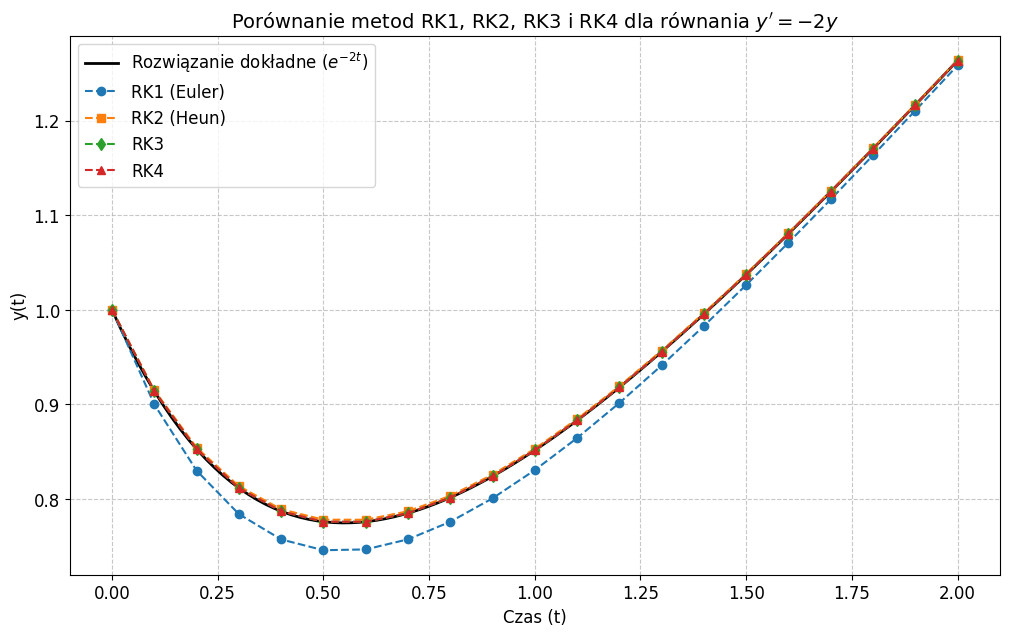

In [ ]:
# Wykres
plt.figure(figsize=(12, 7))
plt.plot(t_exact, y_exact, 'k-', linewidth=2, label='Rozwiązanie dokładne ($e^{-2t}$)')
plt.plot(t_rk1, y_rk1, 'o--', label='RK1 (Euler)')
plt.plot(t_rk2, y_rk2, 's--', label='RK2 (Heun)')
plt.plot(t_rk3, y_rk3, 'd--', label='RK3')
plt.plot(t_rk4, y_rk4, '^--', label='RK4')
plt.title('Porównanie metod RK1, RK2, RK3 i RK4 dla równania $y\'=-2y$', fontsize=14)
plt.xlabel('Czas (t)', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()